In [1]:
import network
import pandas as pd
import geopandas as gpd
import numpy as np
from datetime import datetime
import importlib
importlib.reload(network)
import matplotlib.pyplot as plt
import types
from IPython.display import clear_output
import os
import seaborn as sns
import osmnx as ox

In [127]:
n = network.Network()
n2 = network.Network()
ex = 'Data/Reseaux/ns_EX_PVR.graphml'
pot = 'Data/Reseaux/ns_POT_PVR.graphml'
trips_od18 = 'Data/od18_extraqit_20250123/od18_extraqit_20250123.csv'
stm_gtfs = 'Data/gtfs_stm/stops.txt'
signals_file = 'Data/feux-circulation.csv'

In [128]:
n.load_n_pot(pot)
n.load_n_ex(ex)
n.load_trips(trips_od18,source_crs=2950)
n2.load_n_pot(pot)
n2.load_n_ex(ex)
n2.load_trips(trips_od18,source_crs=2950)

In [141]:
stops = pd.read_csv(stm_gtfs)
metros = stops[stops['location_type']==1]
metros = gpd.GeoDataFrame(metros,geometry = gpd.points_from_xy(metros.stop_lon,metros.stop_lat),crs = 4326).to_crs(n.crs)
n.transit_stops=metros
n2.transit_stops=metros
signals = pd.read_csv(signals_file)

def add_traffic_signals(signals,network):
    signals = gpd.GeoDataFrame(signals,geometry = gpd.points_from_xy(signals.Longitude,signals.Latitude),crs = 4326).to_crs(n.crs)
    network.traffic_signals=signals
    near_traffic_signals = gpd.sjoin_nearest(n.n_pot_nodes,n.traffic_signals,max_distance=15,how = 'left')
    near_traffic_signals = near_traffic_signals[~near_traffic_signals.index.duplicated(keep='first')]
    network.n_pot_nodes['traffic_signals'] = near_traffic_signals.index_right.notna()


In [159]:
cost_reduction_factor = 0.7
np.random.seed(123)
n.reset_network()
n.add_edge_grades('Data/Elevation/output_AW3D30_32618_us.tif')
n.reset_routes()
n.reset_sample()
n.trips_within = n.trips_within[n.trips_within['mode']!='TC']
n.weight_network(cycleway_reduc_factor=cost_reduction_factor,grades=True)
n.sample_trips()
n.add_edge_bearing()
add_traffic_signals(signals,n)
n.get_personal_spatial_features(1,1)

In [96]:
n2.reset_network()
n2.add_edge_grades('Data/Elevation/output_AW3D30_32618_us.tif')
n2.reset_routes()
n2.reset_sample()
n2.trips_within = n2.trips_within[n2.trips_within['mode']!='TC']
n2.weight_network(cycleway_reduc_factor=cost_reduction_factor,grades=True)
n2.sample_trips()
n2.add_edge_bearing()
add_traffic_signals(signals,n2)
n2.get_personal_spatial_features(1,1)

In [160]:
cost_reduction_factor = 0.7
proximity_dist = 10
beta_age = 0
beta_bikeway = 5
beta_transit = 1
icp = 50
ltp = 6*icp
rtp = 2*icp
tsp = 2*icp
mu_age = 25
scale_age = 5
alpha = .2
B = 0
build_dmin=500

name = input('Filename:')
date_time_str = datetime.now().strftime('%m-%d')
n.run_algo2(budget = B,savepath=f'Figures/reseaux/{name}-{date_time_str}',
            buffer = 500,icp = icp, ltp = ltp,rtp = rtp,tsp = tsp,
            cost_reduction_factor = cost_reduction_factor,proximity_dist=proximity_dist,beta_age = beta_age,mu_age = mu_age,scale_age = scale_age, 
            beta_bikeway = beta_bikeway,
            beta_transit = beta_transit,
            alpha = alpha,
            build_dmin=build_dmin,
            backup_every=10,metric = 'completion',turn_penalties=True)

Filename: recomputing


Initializing, computing desire boxes...
Dominating angle: 30.72118686208792
Computing routes...


  0%|          | 0/2411 [00:00<?, ?it/s]

96.39153878058897 % of solved routes,  0.08295313148071339  % of static routes
Computing route metrics...


C:\Users\latitude\Desktop\Recherche\Algo_reseaux\network.py:386: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.007168488348182133 0.007603121396532754 0.007603121396532754 ...
 0.0004590317131440546 0.007603121396532754 0.008458470435251796]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  self.routes_summary.loc[subsample_idxs,'generalized_benefit']+=((self.routes_summary.loc[subsample_idxs]['transit_min_dist']<proximity_dist)*beta_transit*np.std(self.routes_summary.loc[subsample_idxs,'generalized_benefit'])


Network backup at Figures/reseaux/recomputing-11-25


C:\Users\latitude\Desktop\Recherche\Algo_reseaux\network.py:737: UserWarning: The GeoSeries you are attempting to plot is composed of empty geometries. Nothing has been displayed.
  new_network = built_edges.explore(tiles = tiles,


length = 0.0 km


In [97]:
name = input('Filename:')
date_time_str = datetime.now().strftime('%m-%d')
n2.run_algo2(budget = B,savepath=f'Figures/reseaux/{name}-{date_time_str}',
            buffer = 500,icp = icp, ltp = ltp,rtp = rtp,tsp = tsp,
            cost_reduction_factor = cost_reduction_factor,proximity_dist=proximity_dist,beta_age = beta_age,mu_age = mu_age,scale_age = scale_age, 
            beta_bikeway = beta_bikeway,
            beta_transit = beta_transit,
            alpha = alpha,
            build_dmin=build_dmin,
            backup_every=10,metric = 'completion',turn_penalties=True,recompute_routes=False)

Built 59.08777404135873/60 km (iteration 110)
Adding route  29326 (benefit = 0.014349230466437279,length = 1424.7586278851038)
Computing route metrics...
Network backup at Figures/reseaux/no_recomputing-11-25


length = 60.51547153304932 km


In [98]:
l1 = [n.n_ex_edges[n.n_ex_edges.build_iter<=i]['length'].sum() for i in range(1,max(n.n_ex_edges.build_iter))]
l2 = [n2.n_ex_edges[n2.n_ex_edges.build_iter<=i]['length'].sum() for i in range(1,max(n2.n_ex_edges.build_iter))]


In [108]:
cr1 = [len(e[e.prop_cycleway>0.99]) for e in n.evol]
cr2 = [len(e[e.prop_cycleway>0.99]) for e in n2.evol]

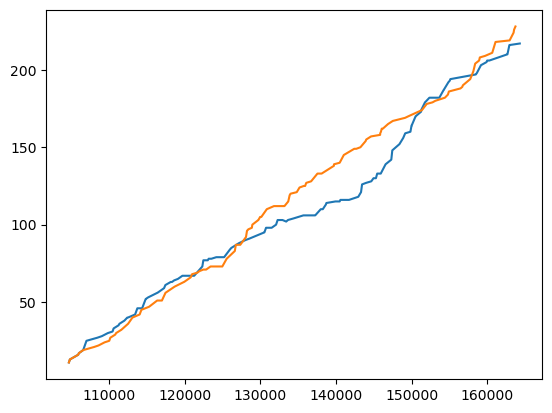

In [109]:
plt.plot(l1,cr1[1:-1])
plt.plot(l2,cr2[1:-1])

In [103]:
rec = n.n_ex_edges[n.n_ex_edges.build_iter>0]
norec = n2.n_ex_edges[n2.n_ex_edges.build_iter>0]
both = pd.merge(rec,norec,right_index=True,left_index=True)

In [104]:
difference = n.n_pot_edges.loc[list(set(rec.index).symmetric_difference(set(norec.index)))]

In [105]:
m = both.set_geometry('geometry_x').explore(tiles = 'CartoDB Positron')
difference.explore(m=m,color = 'red')

In [171]:
both['length_x'].sum()

np.float64(37157.81248295675)

In [179]:
print(rec.loc[rec.index.isin(both.index)]['length'].sum()/rec['length'].sum()*100)
print(norec.loc[norec.index.isin(both.index)]['length'].sum()/norec['length'].sum()*100)


59.58746720111051
61.461696100474185


In [111]:
n_mtl = network.Network()
ex = 'Data/Reseaux/ns_EX_MTL.graphml'
pot = 'Data/Reseaux/ns_POT_MTL.graphml'
n_mtl.load_n_pot(pot)
n_mtl.load_n_ex(ex)
n_mtl.load_trips(trips_od18,source_crs=2950)

In [112]:
n_mtl.transit_stops=metros
cost_reduction_factor = 0.7
n_mtl.reset_network()
n_mtl.add_edge_grades('Data/Elevation/output_AW3D30_32618_us.tif')
n_mtl.reset_routes()
n_mtl.reset_sample()
n_mtl.trips_within = n_mtl.trips_within[n_mtl.trips_within['mode']!='TC']
n_mtl.weight_network(cycleway_reduc_factor=cost_reduction_factor,grades=True)
n_mtl.sample_trips()
n_mtl.add_edge_bearing()
add_traffic_signals(signals,n_mtl)
n_mtl.get_personal_spatial_features(1,1)

ValueError: 'left_df' should be GeoDataFrame, got <class 'NoneType'>

In [169]:
idx = n.routes_summary[n.routes_summary.n_near_completed_routes == 5].sample().index.values[0]
compl_idx = n.routes_summary.loc[idx].near_completed_routes.tolist()
m = n.all_routes_edges[n.all_routes_edges.route_number == idx].explore(tiles = 'CartoDB Positron',style_kwds = {'weight':5})
n.all_routes_edges[n.all_routes_edges.route_number.isin(compl_idx)].explore(m=m,style_kwds = {"dashArray": "5, 5",'color':'black'})
n.n_ex_edges.explore(color = 'red',m=m)